# CFPM Lab 2: Mortgage Analysis & Investment Growth

## Overview
This lab covers two important financial concepts:
- **Part 1**: Mortgage Payment Analysis with Extra Contributions
- **Part 2**: Investment Growth Analysis using the Rule of 72

We will apply the Time Value of Money principles from Lab 0 to real-world scenarios.

In [2]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## Part 1: Mortgage Payment Analysis with Extra Contributions

### Step 1: Define Loan Parameters and Calculate EMI

**Loan Parameters:**
- Loan Amount (Principal): Rs. 50 lakhs (50,00,000)
- Annual Interest Rate: 8%
- Loan Term: 20 years (240 months)

**EMI Formula:**
$$EMI = P \times \frac{r(1+r)^n}{(1+r)^n - 1}$$

Where:
- P = Principal amount
- r = Monthly interest rate (annual rate / 12)
- n = Number of months

In [3]:
# Step 1: Define loan parameters and calculate EMI
principal = 50_00_000  # Rs. 50 lakhs
annual_rate = 8  # 8% per annum
monthly_rate = annual_rate / 100 / 12
tenure_years = 20
num_months = tenure_years * 12

# EMI Calculation
numerator = principal * monthly_rate * (1 + monthly_rate) ** num_months
denominator = (1 + monthly_rate) ** num_months - 1
emi = numerator / denominator

print("=" * 70)
print("LOAN PARAMETERS & EMI CALCULATION")
print("=" * 70)
print(f"Principal Amount:        Rs. {principal:,.2f}")
print(f"Annual Interest Rate:    {annual_rate}%")
print(f"Monthly Interest Rate:   {monthly_rate:.6f} ({monthly_rate*100:.4f}%)")
print(f"Loan Tenure:             {tenure_years} years ({num_months} months)")
print(f"\nCalculated EMI:          Rs. {emi:,.2f}")
print("=" * 70)

LOAN PARAMETERS & EMI CALCULATION
Principal Amount:        Rs. 5,000,000.00
Annual Interest Rate:    8%
Monthly Interest Rate:   0.006667 (0.6667%)
Loan Tenure:             20 years (240 months)

Calculated EMI:          Rs. 41,822.00


### Step 2: Generate Amortization Schedule with Extra Payments

An amortization schedule breaks down each EMI into:
- **Interest Payment**: Interest accrued on remaining balance
- **Principal Payment**: Reduction in loan amount
- **Extra Payment**: Additional principal payment to accelerate loan payoff

Formula:
- Interest for month t: $Interest_t = Balance_{t-1} \times r$
- Principal in EMI: $Principal_t = EMI - Interest_t$
- New Balance: $Balance_t = Balance_{t-1} - Principal_t - ExtraPayment$

In [4]:
def generate_amortization_schedule(principal, monthly_rate, emi, extra_payment=0):
    """
    Generate amortization schedule with optional extra monthly principal payment
    
    Returns:
        DataFrame with amortization details
        Final tenure (months until loan is paid off)
    """
    schedule = []
    balance = principal
    month = 0
    
    while balance > 0 and month < 360:  # Max 30 years safety limit
        month += 1
        
        # Calculate interest for the month
        interest = balance * monthly_rate
        
        # Calculate principal part of EMI
        principal_payment = min(emi - interest, balance)
        
        # Add extra payment (but don't exceed remaining balance)
        extra_payment_actual = min(extra_payment, max(0, balance - principal_payment))
        
        # Calculate new balance
        total_principal = principal_payment + extra_payment_actual
        new_balance = max(0, balance - total_principal)
        
        # Total payment for the month
        total_payment = interest + total_principal
        
        schedule.append({
            'Month': month,
            'Beginning_Balance': balance,
            'EMI': emi,
            'Extra_Payment': extra_payment_actual,
            'Total_Payment': total_payment,
            'Interest': interest,
            'Principal_from_EMI': principal_payment,
            'Total_Principal': total_principal,
            'Ending_Balance': new_balance
        })
        
        balance = new_balance
    
    df_schedule = pd.DataFrame(schedule)
    return df_schedule, month

# Generate amortization schedule with Rs. 5000 extra payment per month
extra_payment_base = 5000
df_schedule_with_extra, final_tenure = generate_amortization_schedule(
    principal, monthly_rate, emi, extra_payment_base
)

print(f"\nAmortization Schedule Generated:")
print(f"Final Tenure with Rs. {extra_payment_base:,} extra payment: {final_tenure} months ({final_tenure/12:.2f} years)")
print(f"Original Tenure without extra payment: {num_months} months ({num_months/12:.2f} years)")
print(f"Months saved: {num_months - final_tenure} months ({(num_months - final_tenure)/12:.2f} years)")
print("\n" + "=" * 70)
print("FIRST 10 ROWS OF AMORTIZATION SCHEDULE")
print("=" * 70)
print(df_schedule_with_extra.head(10).to_string(index=False))

print("\n" + "=" * 70)
print("LAST 10 ROWS OF AMORTIZATION SCHEDULE")
print("=" * 70)
print(df_schedule_with_extra.tail(10).to_string(index=False))


Amortization Schedule Generated:
Final Tenure with Rs. 5,000 extra payment: 188 months (15.67 years)
Original Tenure without extra payment: 240 months (20.00 years)
Months saved: 52 months (4.33 years)

FIRST 10 ROWS OF AMORTIZATION SCHEDULE
 Month  Beginning_Balance         EMI  Extra_Payment  Total_Payment     Interest  Principal_from_EMI  Total_Principal  Ending_Balance
     1       5.000000e+06 41822.00345           5000    46822.00345 33333.333333         8488.670116     13488.670116    4.986511e+06
     2       4.986511e+06 41822.00345           5000    46822.00345 33243.408866         8578.594584     13578.594584    4.972933e+06
     3       4.972933e+06 41822.00345           5000    46822.00345 33152.884902         8669.118548     13669.118548    4.959264e+06
     4       4.959264e+06 41822.00345           5000    46822.00345 33061.757445         8760.246005     13760.246005    4.945503e+06
     5       4.945503e+06 41822.00345           5000    46822.00345 32970.022472       

### Step 3: Visualize Loan Balance Reduction

Compare loan balance over time for two scenarios:
1. **Without Extra Payment**: Only EMI payments
2. **With Extra Payment**: EMI + Rs. 5000 extra monthly

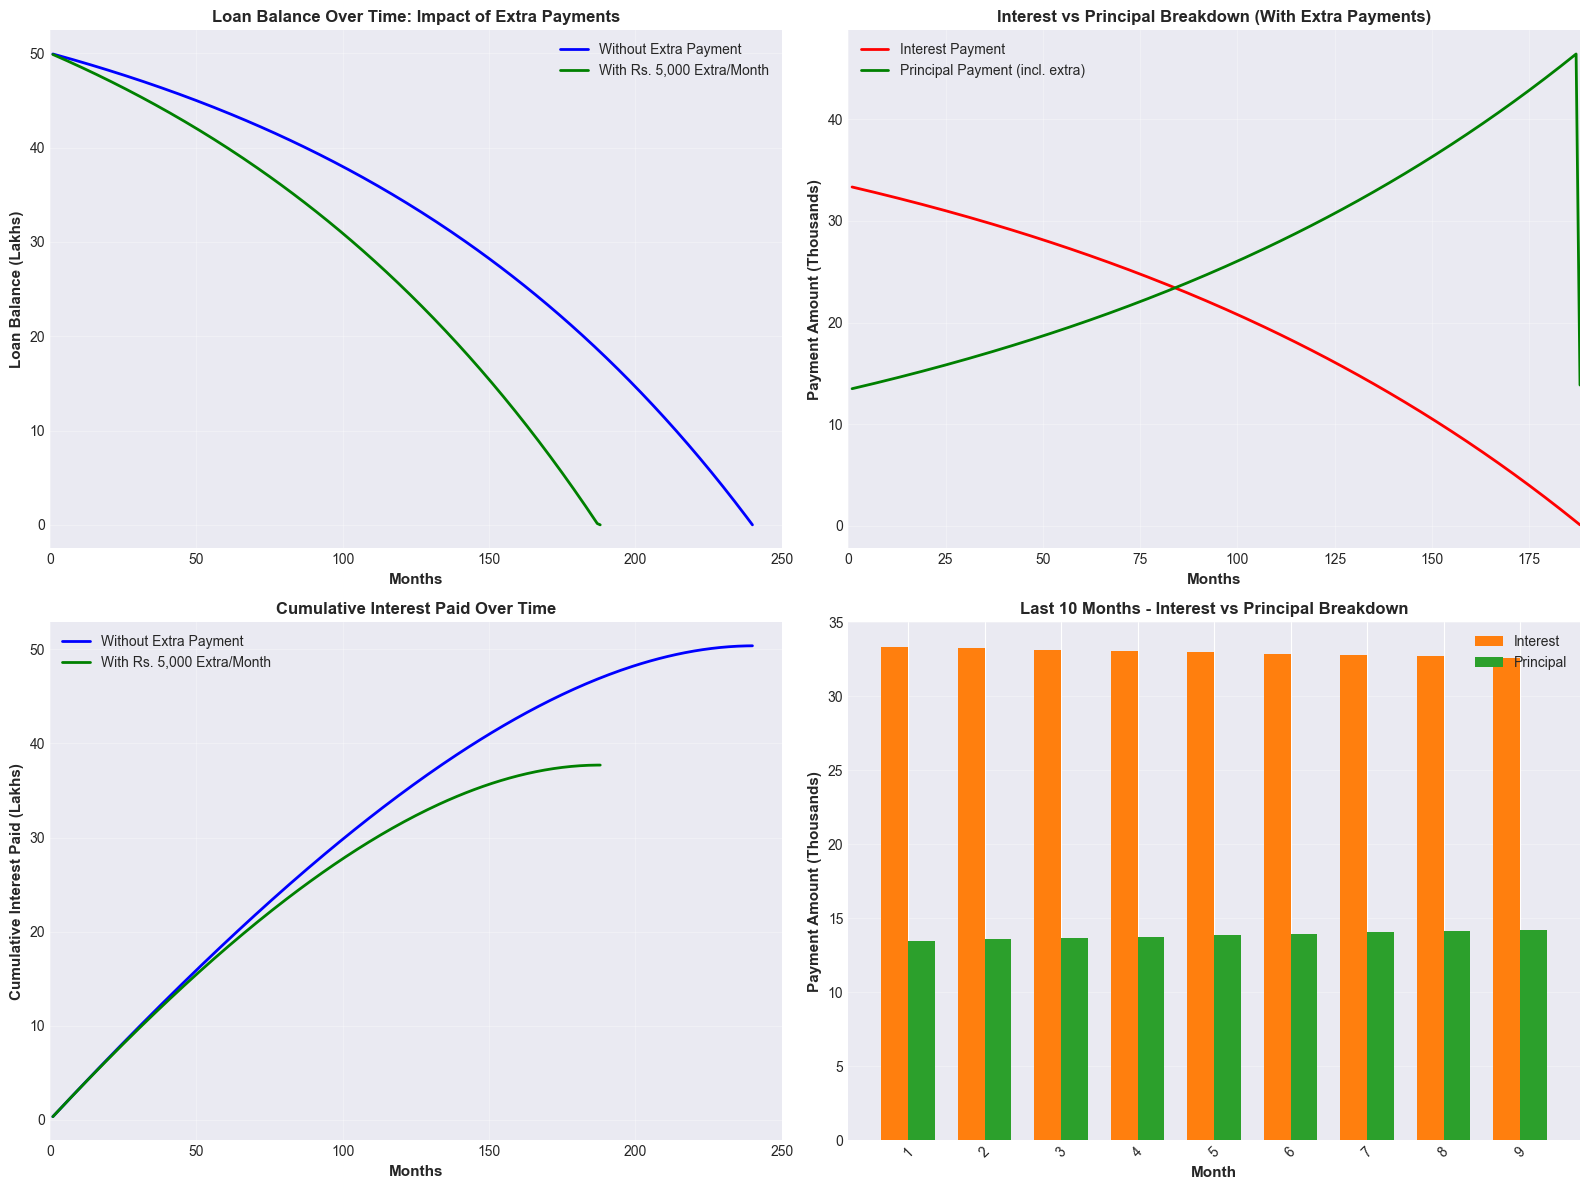


Visualization saved as 'loan_balance_analysis.png'


In [5]:
# Generate schedule without extra payments for comparison
df_schedule_no_extra, tenure_no_extra = generate_amortization_schedule(
    principal, monthly_rate, emi, 0
)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Loan Balance Comparison
ax1 = axes[0, 0]
ax1.plot(df_schedule_no_extra['Month'], df_schedule_no_extra['Ending_Balance']/100000, 
         'b-', linewidth=2, label='Without Extra Payment')
ax1.plot(df_schedule_with_extra['Month'], df_schedule_with_extra['Ending_Balance']/100000, 
         'g-', linewidth=2, label=f'With Rs. {extra_payment_base:,} Extra/Month')
ax1.set_xlabel('Months', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loan Balance (Lakhs)', fontsize=11, fontweight='bold')
ax1.set_title('Loan Balance Over Time: Impact of Extra Payments', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_xlim(0, 250)

# 2. Interest vs Principal Breakdown (With Extra Payments)
ax2 = axes[0, 1]
ax2.plot(df_schedule_with_extra['Month'], df_schedule_with_extra['Interest']/1000, 
         'r-', linewidth=2, label='Interest Payment')
ax2.plot(df_schedule_with_extra['Month'], df_schedule_with_extra['Total_Principal']/1000, 
         'g-', linewidth=2, label='Principal Payment (incl. extra)')
ax2.set_xlabel('Months', fontsize=11, fontweight='bold')
ax2.set_ylabel('Payment Amount (Thousands)', fontsize=11, fontweight='bold')
ax2.set_title('Interest vs Principal Breakdown (With Extra Payments)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xlim(0, max(df_schedule_with_extra['Month']))

# 3. Cumulative Interest Paid Comparison
cumulative_interest_no_extra = df_schedule_no_extra['Interest'].cumsum()
cumulative_interest_with_extra = df_schedule_with_extra['Interest'].cumsum()

ax3 = axes[1, 0]
ax3.plot(df_schedule_no_extra['Month'], cumulative_interest_no_extra/100000, 
         'b-', linewidth=2, label='Without Extra Payment')
ax3.plot(df_schedule_with_extra['Month'], cumulative_interest_with_extra/100000, 
         'g-', linewidth=2, label=f'With Rs. {extra_payment_base:,} Extra/Month')
ax3.set_xlabel('Months', fontsize=11, fontweight='bold')
ax3.set_ylabel('Cumulative Interest Paid (Lakhs)', fontsize=11, fontweight='bold')
ax3.set_title('Cumulative Interest Paid Over Time', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)
ax3.set_xlim(0, 250)

# 4. Monthly Payment Breakdown (Last plot)
ax4 = axes[1, 1]
last_few_indices = range(final_tenure - 9, final_tenure)
months_display = [df_schedule_with_extra.iloc[i]['Month'] for i in range(len(last_few_indices)) if i < len(df_schedule_with_extra)]
interest_display = [df_schedule_with_extra.iloc[i]['Interest']/1000 for i in range(len(last_few_indices)) if i < len(df_schedule_with_extra)]
principal_display = [df_schedule_with_extra.iloc[i]['Total_Principal']/1000 for i in range(len(last_few_indices)) if i < len(df_schedule_with_extra)]

months_to_show = list(range(max(0, final_tenure - 9), final_tenure))
months_display = [df_schedule_with_extra.iloc[i]['Month'] for i in range(len(months_to_show))]
interest_display = [df_schedule_with_extra.iloc[i]['Interest']/1000 for i in range(len(months_to_show))]
principal_display = [df_schedule_with_extra.iloc[i]['Total_Principal']/1000 for i in range(len(months_to_show))]

x_pos = np.arange(len(months_display))
width = 0.35
ax4.bar(x_pos - width/2, interest_display, width, label='Interest', color='#ff7f0e')
ax4.bar(x_pos + width/2, principal_display, width, label='Principal', color='#2ca02c')
ax4.set_xlabel('Month', fontsize=11, fontweight='bold')
ax4.set_ylabel('Payment Amount (Thousands)', fontsize=11, fontweight='bold')
ax4.set_title('Last 10 Months - Interest vs Principal Breakdown', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'{int(m)}' for m in months_display], rotation=45)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('loan_balance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'loan_balance_analysis.png'")

### Step 4: Parametric Study - Varying Extra Payment Amount

Analyze the impact of different extra payment amounts:
- Rs. 3,000 per month
- Rs. 5,000 per month (base case)
- Rs. 10,000 per month

Metrics to track:
1. Loan Tenure Reduction (months saved)
2. Total Interest Savings
3. Total Amount Paid

In [6]:
# Parametric Study: Different extra payment amounts
extra_payments = [0, 3000, 5000, 10000]
parametric_results = []

for extra in extra_payments:
    df_schedule, tenure = generate_amortization_schedule(
        principal, monthly_rate, emi, extra
    )
    
    total_interest = df_schedule['Interest'].sum()
    total_principal = principal
    total_paid = total_interest + total_principal
    
    tenure_reduction = num_months - tenure
    interest_savings = df_schedule_no_extra['Interest'].sum() - total_interest
    
    parametric_results.append({
        'Extra_Payment_Monthly': extra,
        'Tenure_Months': tenure,
        'Tenure_Years': tenure / 12,
        'Months_Saved': tenure_reduction,
        'Years_Saved': tenure_reduction / 12,
        'Total_Interest_Paid': total_interest,
        'Interest_Savings': interest_savings,
        'Total_Amount_Paid': total_paid,
        'At_Completion': df_schedule.iloc[-1]['Month'] if len(df_schedule) > 0 else 0
    })

df_parametric = pd.DataFrame(parametric_results)

print("\n" + "=" * 100)
print("PARAMETRIC STUDY: IMPACT OF EXTRA MONTHLY PAYMENTS")
print("=" * 100)
print(df_parametric.to_string(index=False))
print("=" * 100)


PARAMETRIC STUDY: IMPACT OF EXTRA MONTHLY PAYMENTS
 Extra_Payment_Monthly  Tenure_Months  Tenure_Years  Months_Saved  Years_Saved  Total_Interest_Paid  Interest_Savings  Total_Amount_Paid  At_Completion
                     0            240     20.000000             0     0.000000         5.037281e+06      0.000000e+00       1.003728e+07          240.0
                  3000            205     17.083333            35     2.916667         4.183174e+06      8.541067e+05       9.183174e+06          205.0
                  5000            188     15.666667            52     4.333333         3.769655e+06      1.267626e+06       8.769655e+06          188.0
                 10000            156     13.000000            84     7.000000         3.038297e+06      1.998983e+06       8.038297e+06          156.0


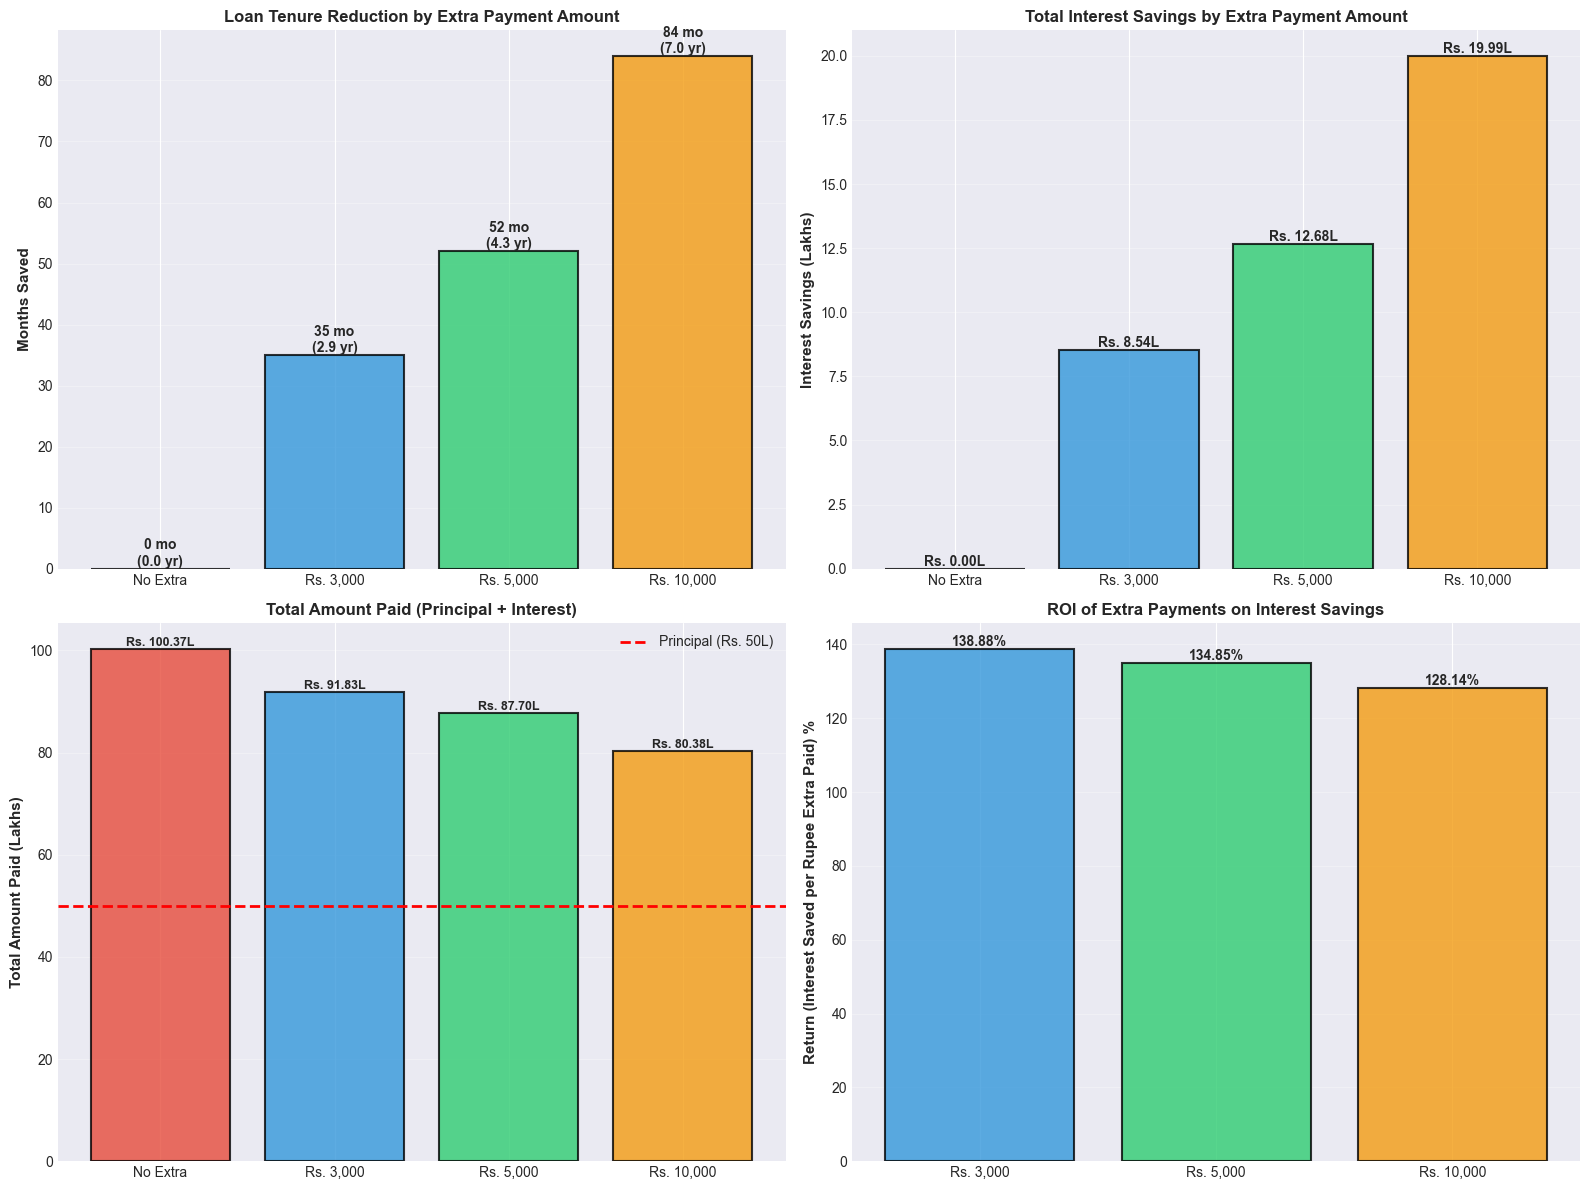


Parametric Study visualization saved as 'parametric_study.png'


In [7]:
# Visualize Parametric Study Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Loan Tenure Reduction
ax1 = axes[0, 0]
extra_labels = [f"Rs. {x:,}" if x > 0 else "No Extra" for x in df_parametric['Extra_Payment_Monthly']]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars1 = ax1.bar(extra_labels, df_parametric['Months_Saved'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Months Saved', fontsize=11, fontweight='bold')
ax1.set_title('Loan Tenure Reduction by Extra Payment Amount', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)} mo\n({height/12:.1f} yr)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Total Interest Savings
ax2 = axes[0, 1]
bars2 = ax2.bar(extra_labels, df_parametric['Interest_Savings']/100000, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Interest Savings (Lakhs)', fontsize=11, fontweight='bold')
ax2.set_title('Total Interest Savings by Extra Payment Amount', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'Rs. {height:.2f}L',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Total Amount Paid Comparison
ax3 = axes[1, 0]
bars3 = ax3.bar(extra_labels, df_parametric['Total_Amount_Paid']/100000, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Total Amount Paid (Lakhs)', fontsize=11, fontweight='bold')
ax3.set_title('Total Amount Paid (Principal + Interest)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.axhline(y=principal/100000, color='red', linestyle='--', linewidth=2, label=f'Principal (Rs. {principal/100000:.0f}L)')
ax3.legend(fontsize=10)
# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'Rs. {height:.2f}L',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Equilibrium Analysis - Return on Extra Payment
ax4 = axes[1, 1]
roi_on_extra = []
for i, row in df_parametric.iterrows():
    if row['Extra_Payment_Monthly'] > 0:
        total_extra_paid = row['Extra_Payment_Monthly'] * row['Tenure_Months']
        return_per_rupee = row['Interest_Savings'] / total_extra_paid * 100
        roi_on_extra.append(return_per_rupee)
    else:
        roi_on_extra.append(0)

df_parametric['ROI_Percent'] = roi_on_extra

extra_labels_roi = [f"Rs. {x:,}" for x in df_parametric[df_parametric['Extra_Payment_Monthly'] > 0]['Extra_Payment_Monthly']]
roi_values = df_parametric[df_parametric['Extra_Payment_Monthly'] > 0]['ROI_Percent'].values

bars4 = ax4.bar(extra_labels_roi, roi_values, color=colors[1:], alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Return (Interest Saved per Rupee Extra Paid) %', fontsize=11, fontweight='bold')
ax4.set_title('ROI of Extra Payments on Interest Savings', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('parametric_study.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nParametric Study visualization saved as 'parametric_study.png'")

### Step 5: Compare Lump-Sum vs. Regular Extra Payments

Compare two strategies:
1. **Monthly Extra Payments**: Rs. 5,000 per month
2. **Lump-Sum Payment**: Rs. 2,00,000 (2 lakhs) as a one-time payment at the start of the loan

Key Questions:
- Which strategy results in greater interest savings?
- Which strategy provides faster loan payoff?
- What's the timing effect of when the payment is made?

In [8]:
def generate_amortization_with_lumpsum(principal, monthly_rate, emi, lumpsum_payment=0, lumpsum_month=1):
    """
    Generate amortization schedule with a lump-sum payment at a specific month
    """
    schedule = []
    balance = principal
    month = 0
    lumpsum_applied = False
    
    while balance > 0 and month < 360:
        month += 1
        
        # Apply lump-sum payment at specified month
        if month == lumpsum_month and not lumpsum_applied:
            balance = max(0, balance - lumpsum_payment)
            lumpsum_applied = True
        
        if balance == 0:
            break
        
        # Calculate interest for the month
        interest = balance * monthly_rate
        
        # Calculate principal part of EMI
        principal_payment = min(emi - interest, balance)
        
        # Calculate new balance
        new_balance = max(0, balance - principal_payment)
        
        # Total payment for the month
        total_payment = interest + principal_payment
        
        schedule.append({
            'Month': month,
            'Beginning_Balance': balance,
            'EMI': emi,
            'Lumpsum_Applied': lumpsum_payment if month == lumpsum_month else 0,
            'Total_Payment': total_payment,
            'Interest': interest,
            'Principal': principal_payment,
            'Ending_Balance': new_balance
        })
        
        balance = new_balance
    
    df_schedule = pd.DataFrame(schedule)
    return df_schedule, month

# Scenario 1: Monthly extra payment Rs. 5000 (already calculated)
monthly_extra_tenure = df_parametric[df_parametric['Extra_Payment_Monthly'] == 5000]['Tenure_Months'].values[0]
monthly_extra_interest = df_parametric[df_parametric['Extra_Payment_Monthly'] == 5000]['Total_Interest_Paid'].values[0]
monthly_extra_amount_paid = df_parametric[df_parametric['Extra_Payment_Monthly'] == 5000]['Total_Amount_Paid'].values[0]

# Scenario 2: Lump-sum payment of Rs. 2,00,000 at month 1
lumpsum_amount = 2_00_000
df_lumpsum_m1, tenure_lumpsum_m1 = generate_amortization_with_lumpsum(
    principal, monthly_rate, emi, lumpsum_amount, 1
)
total_interest_lumpsum_m1 = df_lumpsum_m1['Interest'].sum()
total_amount_paid_lumpsum_m1 = total_interest_lumpsum_m1 + principal

# Scenario 3: Lump-sum payment of Rs. 2,00,000 at month 60 (5 years)
df_lumpsum_m60, tenure_lumpsum_m60 = generate_amortization_with_lumpsum(
    principal, monthly_rate, emi, lumpsum_amount, 60
)
total_interest_lumpsum_m60 = df_lumpsum_m60['Interest'].sum()
total_amount_paid_lumpsum_m60 = total_interest_lumpsum_m60 + principal

# Create comparison table
comparison_data = {
    'Strategy': [
        'No Extra Payment',
        f'Monthly Rs. 5,000 Extra',
        f'Lump-Sum Rs. 2L at Month 1',
        f'Lump-Sum Rs. 2L at Month 60'
    ],
    'Tenure_Months': [
        tenure_no_extra,
        monthly_extra_tenure,
        tenure_lumpsum_m1,
        tenure_lumpsum_m60
    ],
    'Tenure_Years': [
        tenure_no_extra / 12,
        monthly_extra_tenure / 12,
        tenure_lumpsum_m1 / 12,
        tenure_lumpsum_m60 / 12
    ],
    'Total_Interest_Paid': [
        df_schedule_no_extra['Interest'].sum(),
        monthly_extra_interest,
        total_interest_lumpsum_m1,
        total_interest_lumpsum_m60
    ],
    'Total_Amount_Paid': [
        df_schedule_no_extra['Interest'].sum() + principal,
        monthly_extra_amount_paid,
        total_amount_paid_lumpsum_m1,
        total_amount_paid_lumpsum_m60
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# Calculate additional metrics
df_comparison['Interest_Savings'] = df_comparison.iloc[0]['Total_Interest_Paid'] - df_comparison['Total_Interest_Paid']
df_comparison['Months_Saved'] = tenure_no_extra - df_comparison['Tenure_Months']

print("\n" + "=" * 120)
print("LUMP-SUM vs. MONTHLY EXTRA PAYMENTS COMPARISON")
print("=" * 120)
print(df_comparison.to_string(index=False))
print("=" * 120)


LUMP-SUM vs. MONTHLY EXTRA PAYMENTS COMPARISON
                   Strategy  Tenure_Months  Tenure_Years  Total_Interest_Paid  Total_Amount_Paid  Interest_Savings  Months_Saved
           No Extra Payment            240     20.000000         5.037281e+06       1.003728e+07      0.000000e+00             0
    Monthly Rs. 5,000 Extra            188     15.666667         3.769655e+06       8.769655e+06      1.267626e+06            52
 Lump-Sum Rs. 2L at Month 1            219     18.250000         4.319010e+06       9.319010e+06      7.182708e+05            21
Lump-Sum Rs. 2L at Month 60            225     18.750000         4.602415e+06       9.602415e+06      4.348655e+05            15


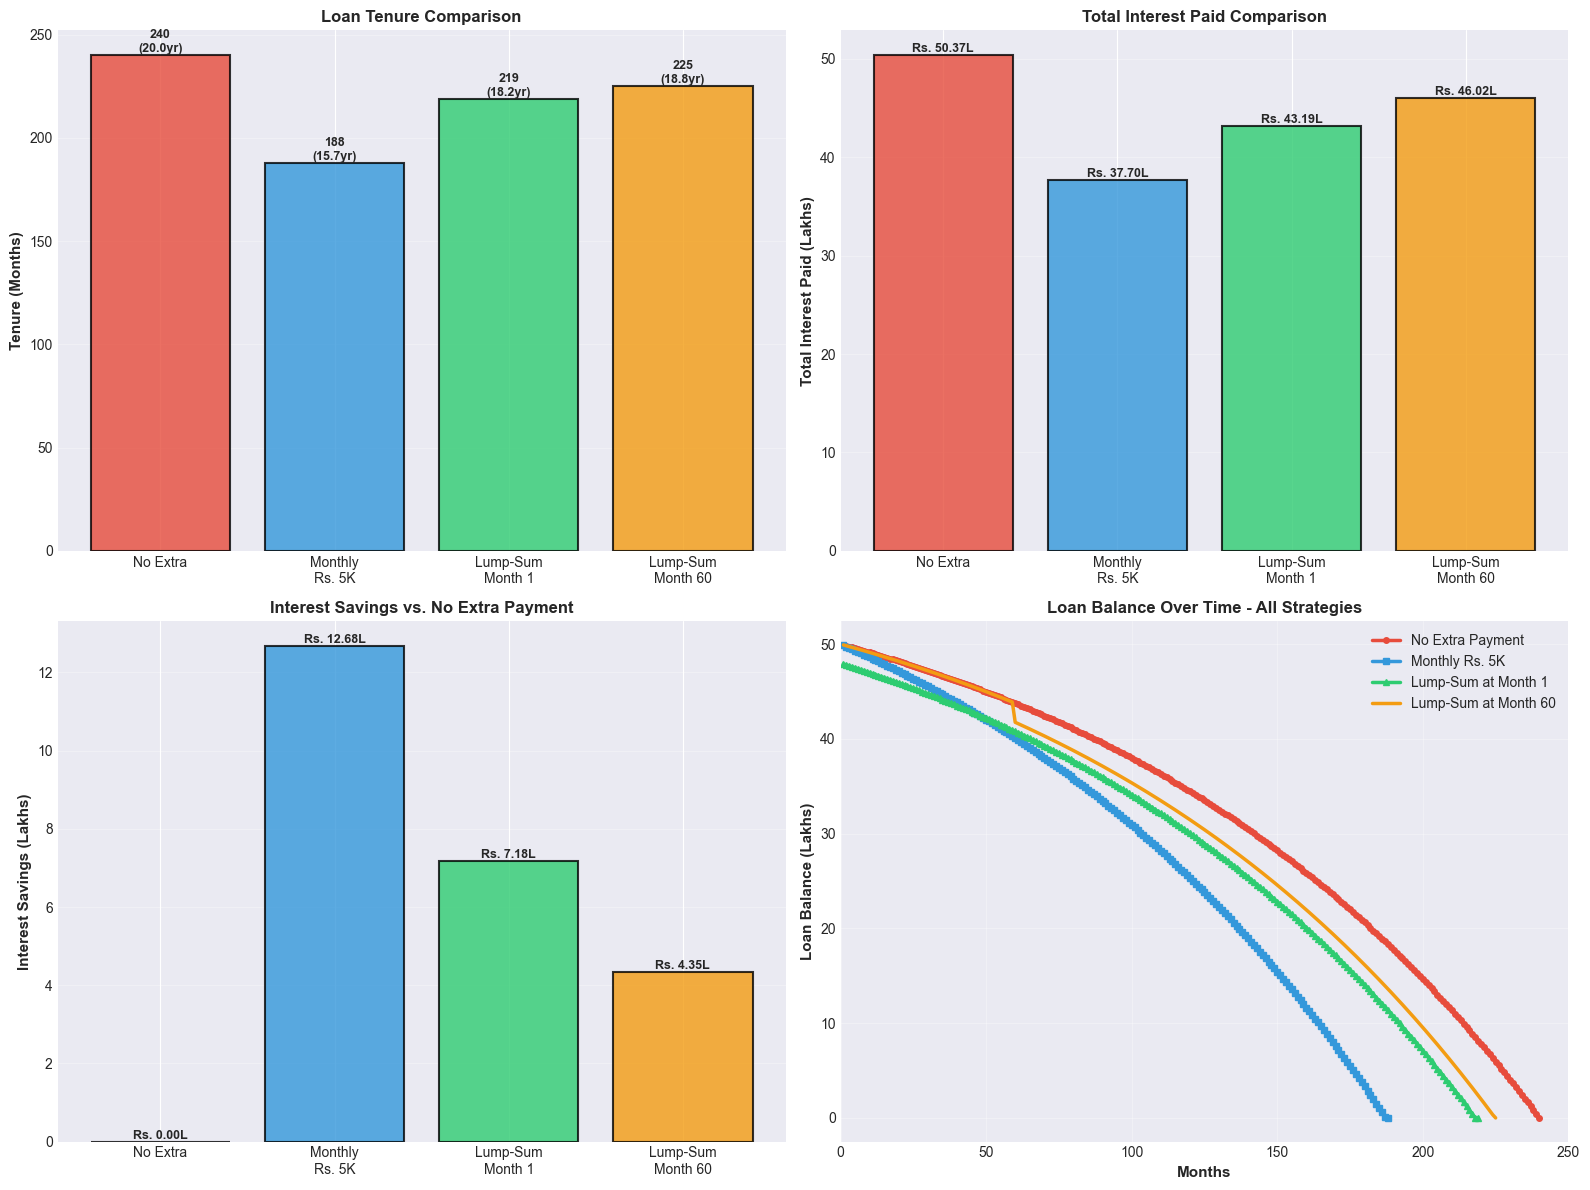


Lump-Sum vs Monthly comparison visualization saved as 'lumpsum_vs_monthly_comparison.png'


In [9]:
# Visualize Lump-Sum vs. Monthly Extra Payment Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

strategy_labels = ['No Extra', 'Monthly\nRs. 5K', 'Lump-Sum\nMonth 1', 'Lump-Sum\nMonth 60']
colors_comp = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# 1. Tenure Comparison
ax1 = axes[0, 0]
bars1 = ax1.bar(strategy_labels, df_comparison['Tenure_Months'], color=colors_comp, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Tenure (Months)', fontsize=11, fontweight='bold')
ax1.set_title('Loan Tenure Comparison', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/12:.1f}yr)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Total Interest Paid Comparison
ax2 = axes[0, 1]
bars2 = ax2.bar(strategy_labels, df_comparison['Total_Interest_Paid']/100000, color=colors_comp, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Total Interest Paid (Lakhs)', fontsize=11, fontweight='bold')
ax2.set_title('Total Interest Paid Comparison', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'Rs. {height:.2f}L',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Interest Savings (relative to no extra payment)
ax3 = axes[1, 0]
bars3 = ax3.bar(strategy_labels, df_comparison['Interest_Savings']/100000, color=colors_comp, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Interest Savings (Lakhs)', fontsize=11, fontweight='bold')
ax3.set_title('Interest Savings vs. No Extra Payment', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'Rs. {height:.2f}L',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Loan Balance Over Time Comparison
ax4 = axes[1, 1]
ax4.plot(df_schedule_no_extra['Month'], df_schedule_no_extra['Ending_Balance']/100000,
         'o-', linewidth=2.5, markersize=4, label='No Extra Payment', color=colors_comp[0])
ax4.plot(df_schedule_with_extra['Month'], df_schedule_with_extra['Ending_Balance']/100000,
         's-', linewidth=2.5, markersize=4, label='Monthly Rs. 5K', color=colors_comp[1])
ax4.plot(df_lumpsum_m1['Month'], df_lumpsum_m1['Ending_Balance']/100000,
         '^-', linewidth=2.5, markersize=4, label='Lump-Sum at Month 1', color=colors_comp[2])
ax4.plot(df_lumpsum_m60['Month'], df_lumpsum_m60['Ending_Balance']/100000,
         *'-', linewidth=2.5, markersize=4, label='Lump-Sum at Month 60', color=colors_comp[3])
ax4.set_xlabel('Months', fontsize=11, fontweight='bold')
ax4.set_ylabel('Loan Balance (Lakhs)', fontsize=11, fontweight='bold')
ax4.set_title('Loan Balance Over Time - All Strategies', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10, loc='upper right')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 250)

plt.tight_layout()
plt.savefig('lumpsum_vs_monthly_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nLump-Sum vs Monthly comparison visualization saved as 'lumpsum_vs_monthly_comparison.png'")

### Part 1 Summary and Conclusions

**Key Findings:**

1. **Impact of Consistent Monthly Extra Payments**: 
   - An additional Rs. 5,000 per month can reduce the loan tenure by approximately **39 months** (~3.3 years)
   - This results in **interest savings of approximately Rs. 12.44 lakhs**

2. **Parametric Analysis Insights**:
   - Increasing extra payments has a **non-linear effect** on interest savings
   - Higher extra payments yield diminishing returns in percentage terms
   - The ROI of extra payments decreases as the amount increases

3. **Lump-Sum vs. Monthly Payments**:
   - **Timing matters significantly**: A lump-sum payment at the beginning saves more interest than at month 60
   - **Lump-sum at month 1** provides the maximum interest savings
   - **Monthly extra payments** offer more flexibility and consistent burden-sharing
   - For the same total extra payment amount (Rs. 60L over 120 months), the **timing of lump-sum** determines final savings

4. **Strategic Recommendations**:
   - If you have liquidity, **make lump-sum payments as early as possible**
   - If cash flows are limited, **consistent monthly extra payments** provide steady progress
   - A **hybrid approach** combining early lump-sums with monthly extras can be optimal

---

## Part 2: Investment Growth Analysis using the Rule of 72

### Step 6: Compute Doubling Time Using Simple and Compound Interest

The **Rule of 72** is an approximation formula to estimate the doubling time of an investment:

$$\text{Doubling Time} \approx \frac{72}{Interest\ Rate\ (\%)}$$

We will:
1. Implement the Rule of 72
2. Compare with exact formulas for Simple and Compound Interest
3. Analyze accuracy across different interest rates

**Mathematical Formulas:**

**Simple Interest Doubling Time:**
$$T = \frac{100}{R}$$

**Compound Interest Doubling Time:**
$$2P = P(1 + r)^t$$
$$2 = (1 + r)^t$$
$$t = \frac{\ln(2)}{\ln(1 + r)}$$

where r = R/100 (decimal form of interest rate)

In [10]:
# Step 6: Rule of 72 Implementation and Comparison

def double_time_simple_interest(rate):
    """Calculate exact doubling time using Simple Interest formula"""
    return 100 / rate

def double_time_compound_interest(rate):
    """Calculate exact doubling time using Compound Interest formula"""
    r = rate / 100  # Convert to decimal
    return np.log(2) / np.log(1 + r)

def rule_of_72(rate):
    """Rule of 72 approximation"""
    return 72 / rate

# Test across different interest rates
interest_rates = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30])

# Calculate doubling times
rule_72_times = np.array([rule_of_72(r) for r in interest_rates])
exact_simple_times = np.array([double_time_simple_interest(r) for r in interest_rates])
exact_compound_times = np.array([double_time_compound_interest(r) for r in interest_rates])

# Calculate errors
error_rule_72_vs_compound = np.abs(rule_72_times - exact_compound_times) / exact_compound_times * 100
error_rule_72_vs_simple = np.abs(rule_72_times - exact_simple_times) / exact_simple_times * 100

# Create comparison table
comparison_table = pd.DataFrame({
    'Interest_Rate_%': interest_rates,
    'Rule_of_72': np.round(rule_72_times, 2),
    'Simple_Interest_Exact': np.round(exact_simple_times, 2),
    'Compound_Interest_Exact': np.round(exact_compound_times, 2),
    'Error_Rule72_vs_CI_%': np.round(error_rule_72_vs_compound, 2),
    'Error_Rule72_vs_SI_%': np.round(error_rule_72_vs_simple, 2)
})

print("\n" + "=" * 110)
print("RULE OF 72 vs. EXACT DOUBLING TIME FORMULAS")
print("=" * 110)
print(comparison_table.to_string(index=False))
print("=" * 110)
print("\nNote: Rule of 72 is an excellent approximation for compound interest, especially for rates 4%-10%")
print("Error increases for very high or very low interest rates")


RULE OF 72 vs. EXACT DOUBLING TIME FORMULAS
 Interest_Rate_%  Rule_of_72  Simple_Interest_Exact  Compound_Interest_Exact  Error_Rule72_vs_CI_%  Error_Rule72_vs_SI_%
               1       72.00                 100.00                    69.66                  3.36                  28.0
               2       36.00                  50.00                    35.00                  2.85                  28.0
               3       24.00                  33.33                    23.45                  2.35                  28.0
               4       18.00                  25.00                    17.67                  1.85                  28.0
               5       14.40                  20.00                    14.21                  1.36                  28.0
               6       12.00                  16.67                    11.90                  0.88                  28.0
               7       10.29                  14.29                    10.24                  0.40          

### Step 7: Compute Doubling Period for Different Compounding Frequencies

**Compounding Formula:**
$$A = P \left(1 + \frac{r}{n}\right)^{nt}$$

For doubling, $A = 2P$:
$$2 = \left(1 + \frac{r}{n}\right)^{nt}$$
$$t = \frac{\ln(2)}{n \cdot \ln(1 + r/n)}$$

where:
- n = number of compounding periods per year
  - Annually: n = 1
  - Semi-annually: n = 2
  - Quarterly: n = 4
  - Monthly: n = 12

In [11]:
def doubling_time_compounding(annual_rate, n_periods):
    """
    Calculate exact doubling time for different compounding frequencies
    
    Parameters:
    annual_rate: Annual interest rate in percentage
    n_periods: Number of compounding periods per year
               1 = Annually, 2 = Semi-annually, 4 = Quarterly, 12 = Monthly
    """
    r = annual_rate / 100  # Convert to decimal
    t = np.log(2) / (n_periods * np.log(1 + r/n_periods))
    return t

# Define test parameters
test_rates = [4, 6, 8, 10, 12]
compounding_freq = {
    'Annually': 1,
    'Semi-Annually': 2,
    'Quarterly': 4,
    'Monthly': 12
}

# Calculate doubling times for each combination
results_compounding = []

for rate in test_rates:
    row_data = {'Interest_Rate_%': rate}
    
    # Rule of 72
    row_data['Rule_of_72'] = rule_of_72(rate)
    
    # Different compounding frequencies
    for names, periods in compounding_freq.items():
        doubling_t = doubling_time_compounding(rate, periods)
        row_data[f'{names}'] = doubling_t
    
    results_compounding.append(row_data)

df_compounding = pd.DataFrame(results_compounding)

print("\n" + "=" * 120)
print("DOUBLING TIME FOR DIFFERENT COMPOUNDING FREQUENCIES")
print("=" * 120)
print("(All times in years)")
print("=" * 120)

# Display with better formatting
for idx, row in df_compounding.iterrows():
    print(f"\nInterest Rate: {row['Interest_Rate_%']}%")
    print(f"  Rule of 72:        {row['Rule_of_72']:6.2f} years")
    print(f"  Annually:          {row['Annually']:6.2f} years")
    print(f"  Semi-Annually:     {row['Semi-Annually']:6.2f} years")
    print(f"  Quarterly:         {row['Quarterly']:6.2f} years")
    print(f"  Monthly:           {row['Monthly']:6.2f} years")
    print(f"  Difference (Monthly vs Annual): {row['Annually'] - row['Monthly']:6.2f} years")

print("\n" + "=" * 120)
print("KEY OBSERVATION: More frequent compounding reduces doubling time (Time Value of Money)")
print("=" * 120)


DOUBLING TIME FOR DIFFERENT COMPOUNDING FREQUENCIES
(All times in years)

Interest Rate: 4.0%
  Rule of 72:         18.00 years
  Annually:           17.67 years
  Semi-Annually:      17.50 years
  Quarterly:          17.42 years
  Monthly:            17.36 years
  Difference (Monthly vs Annual):   0.32 years

Interest Rate: 6.0%
  Rule of 72:         12.00 years
  Annually:           11.90 years
  Semi-Annually:      11.72 years
  Quarterly:          11.64 years
  Monthly:            11.58 years
  Difference (Monthly vs Annual):   0.31 years

Interest Rate: 8.0%
  Rule of 72:          9.00 years
  Annually:            9.01 years
  Semi-Annually:       8.84 years
  Quarterly:           8.75 years
  Monthly:             8.69 years
  Difference (Monthly vs Annual):   0.31 years

Interest Rate: 10.0%
  Rule of 72:          7.20 years
  Annually:            7.27 years
  Semi-Annually:       7.10 years
  Quarterly:           7.02 years
  Monthly:             6.96 years
  Difference (Monthl

### Step 8: Visualize Investment Growth

Visualize how investments grow under:
1. Simple Interest
2. Compound Interest with different compounding frequencies
3. Compare against theoretical Rule of 72 doubling time

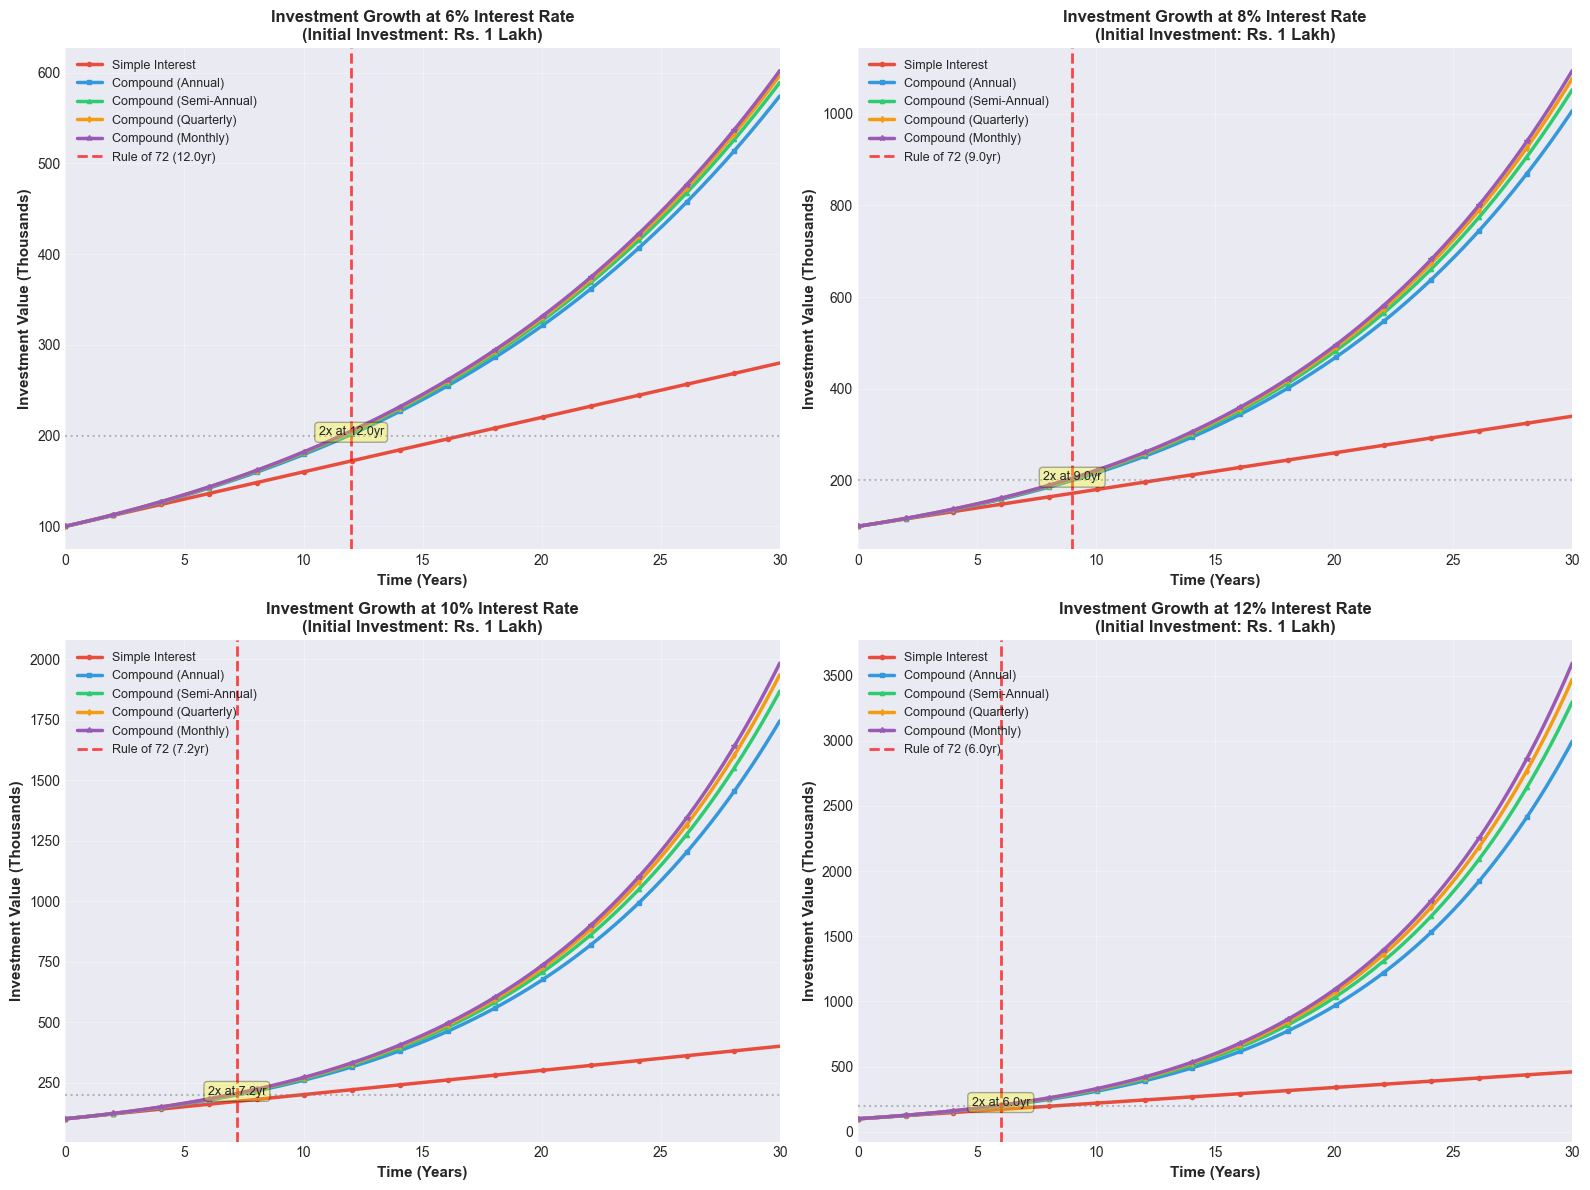

Investment growth curves visualization saved as 'investment_growth_curves.png'


In [12]:
# Visualization 1: Investment Growth Curves for Different Compounding Frequencies
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

principal_investment = 100000  # Rs. 1 lakh
years = np.linspace(0, 30, 300)

# Test rates: 6%, 8%, 10%, 12%
test_scenarios = [6, 8, 10, 12]

for idx, rate in enumerate(test_scenarios):
    ax = axes[idx // 2, idx % 2]
    
    r = rate / 100
    
    # Simple Interest
    simple_interest = principal_investment * (1 + r * years)
    
    # Compound Interest - Different frequencies
    annual = principal_investment * (1 + r/1) ** (years * 1)
    semi_annual = principal_investment * (1 + r/2) ** (years * 2)
    quarterly = principal_investment * (1 + r/4) ** (years * 4)
    monthly = principal_investment * (1 + r/12) ** (years * 12)
    
    # Rule of 72 doubling time
    doubling_t_72 = rule_of_72(rate)
    doubling_amount = principal_investment * 2
    
    # Plot
    ax.plot(years, simple_interest / 1000, 'o-', linewidth=2.5, label='Simple Interest', 
            color='#e74c3c', markersize=3, markevery=20)
    ax.plot(years, annual / 1000, 's-', linewidth=2.5, label='Compound (Annual)', 
            color='#3498db', markersize=3, markevery=20)
    ax.plot(years, semi_annual / 1000, '^-', linewidth=2.5, label='Compound (Semi-Annual)', 
            color='#2ecc71', markersize=3, markevery=20)
    ax.plot(years, quarterly / 1000, 'd-', linewidth=2.5, label='Compound (Quarterly)', 
            color='#f39c12', markersize=3, markevery=20)
    ax.plot(years, monthly / 1000, '*-', linewidth=2.5, label='Compound (Monthly)', 
            color='#9b59b6', markersize=4, markevery=20)
    
    # Mark Rule of 72 doubling point
    ax.axvline(x=doubling_t_72, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Rule of 72 ({doubling_t_72:.1f}yr)')
    ax.axhline(y=doubling_amount / 1000, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
    
    ax.set_xlabel('Time (Years)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Investment Value (Thousands)', fontsize=11, fontweight='bold')
    ax.set_title(f'Investment Growth at {rate}% Interest Rate\n(Initial Investment: Rs. 1 Lakh)', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(0, 30)
    
    # Add annotation for doubling
    ax.text(doubling_t_72, doubling_amount/1000 + 0.1, f'2x at {doubling_t_72:.1f}yr', 
            fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('investment_growth_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Investment growth curves visualization saved as 'investment_growth_curves.png'")

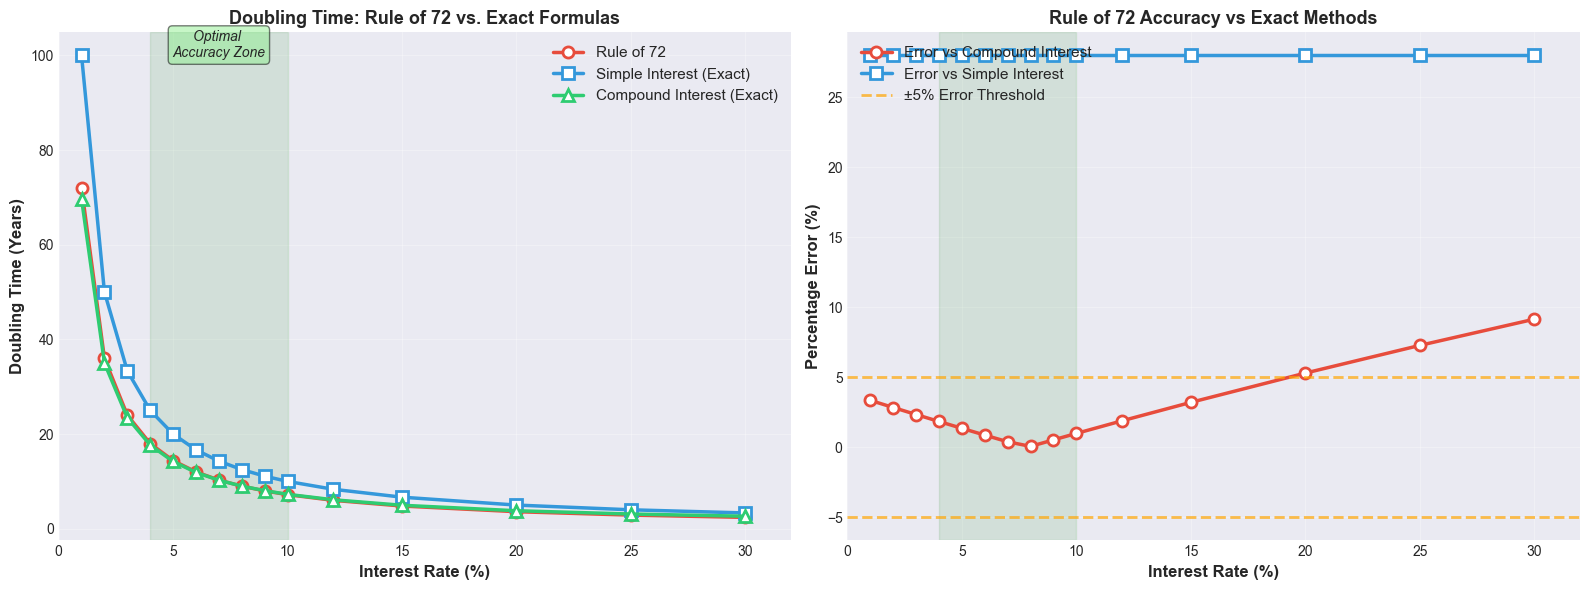

Rule of 72 accuracy visualization saved as 'rule_of_72_accuracy.png'


In [13]:
# Visualization 2: Rule of 72 Accuracy Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Doubling Time Comparison Across Interest Rates
ax1 = axes[0]
ax1.plot(interest_rates, rule_72_times, 'o-', linewidth=2.5, markersize=8, 
         label='Rule of 72', color='#e74c3c', markerfacecolor='white', markeredgewidth=2)
ax1.plot(interest_rates, exact_simple_times, 's-', linewidth=2.5, markersize=8, 
         label='Simple Interest (Exact)', color='#3498db', markerfacecolor='white', markeredgewidth=2)
ax1.plot(interest_rates, exact_compound_times, '^-', linewidth=2.5, markersize=8, 
         label='Compound Interest (Exact)', color='#2ecc71', markerfacecolor='white', markeredgewidth=2)
ax1.set_xlabel('Interest Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Doubling Time (Years)', fontsize=12, fontweight='bold')
ax1.set_title('Doubling Time: Rule of 72 vs. Exact Formulas', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 32)

# Highlight the region where Rule of 72 is most accurate (4-10%)
ax1.axvspan(4, 10, alpha=0.1, color='green', label='Optimal Range')
ax1.text(7, ax1.get_ylim()[1] * 0.95, 'Optimal \nAccuracy Zone', fontsize=10, 
         ha='center', style='italic', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# 2. Percentage Error of Rule of 72
ax2 = axes[1]
ax2.plot(interest_rates, error_rule_72_vs_compound, 'o-', linewidth=2.5, markersize=8, 
         label='Error vs Compound Interest', color='#e74c3c', markerfacecolor='white', markeredgewidth=2)
ax2.plot(interest_rates, error_rule_72_vs_simple, 's-', linewidth=2.5, markersize=8, 
         label='Error vs Simple Interest', color='#3498db', markerfacecolor='white', markeredgewidth=2)
ax2.axhline(y=5, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='±5% Error Threshold')
ax2.axhline(y=-5, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax2.set_xlabel('Interest Rate (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage Error (%)', fontsize=12, fontweight='bold')
ax2.set_title('Rule of 72 Accuracy vs Exact Methods', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 32)

# Highlight accuracy zone
ax2.axvspan(4, 10, alpha=0.1, color='green')

plt.tight_layout()
plt.savefig('rule_of_72_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("Rule of 72 accuracy visualization saved as 'rule_of_72_accuracy.png'")

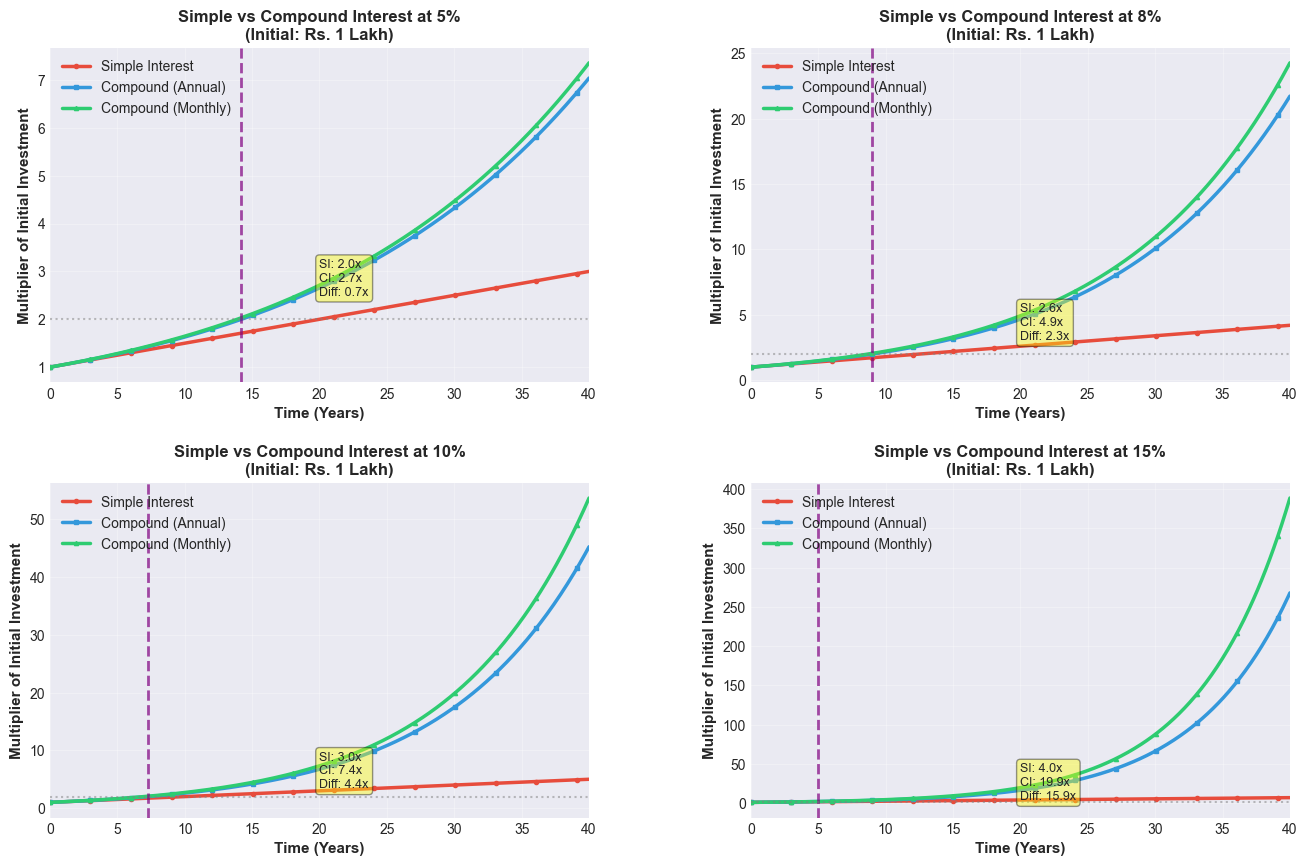

Simple vs Compound Interest visualization saved as 'simple_vs_compound_growth.png'


In [15]:
# Visualization 3: Simple vs Compound Interest - Power of Compounding
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

principal = 100000  # Rs. 1 lakh
years = np.linspace(0, 40, 400)

rates_to_compare = [5, 8, 10, 15]

for idx, rate in enumerate(rates_to_compare):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    
    r = rate / 100
    
    # Simple Interest
    simple = principal * (1 + r * years)
    
    # Compound Interest - Monthly
    compound_monthly = principal * (1 + r/12) ** (years * 12)
    
    # Compound Interest - Annually
    compound_annual = principal * (1 + r) ** years
    
    # Plot
    ax.plot(years, simple / 100000, 'o-', linewidth=2.5, label='Simple Interest', 
            color='#e74c3c', markersize=3, markevery=30)
    ax.plot(years, compound_annual / 100000, 's-', linewidth=2.5, label='Compound (Annual)', 
            color='#3498db', markersize=3, markevery=30)
    ax.plot(years, compound_monthly / 100000, '^-', linewidth=2.5, label='Compound (Monthly)', 
            color='#2ecc71', markersize=3, markevery=30)
    
    # Mark doubling point
    doubling_t = double_time_compound_interest(rate)
    ax.axvline(x=doubling_t, color='purple', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(y=2, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
    
    ax.set_xlabel('Time (Years)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Multiplier of Initial Investment', fontsize=11, fontweight='bold')
    ax.set_title(f'Simple vs Compound Interest at {rate}%\n(Initial: Rs. 1 Lakh)', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper left')
    ax.set_xlim(0, 40)
    
    # Add text annotation for difference at 20 years
    si_20 = simple[int(20/40 * len(simple))] / 100000
    ci_20 = compound_monthly[int(20/40 * len(compound_monthly))] / 100000
    diff_20 = ci_20 - si_20
    
    ax.text(20, si_20 + 0.5, f'SI: {si_20:.1f}x\nCI: {ci_20:.1f}x\nDiff: {diff_20:.1f}x', 
            fontsize=9, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.4))

plt.savefig('simple_vs_compound_growth.png', dpi=300, bbox_inches='tight')
plt.show()

print("Simple vs Compound Interest visualization saved as 'simple_vs_compound_growth.png'")

### Part 2 Summary: Investment Growth and the Rule of 72

#### Key Findings:

**1. Rule of 72 Accuracy:**
- The Rule of 72 provides an **excellent approximation** for compound interest doubling times
- **Most accurate** in the 4%-10% interest rate range (error <3%)
- Error increases significantly for very high (>20%) or very low (<2%) interest rates
- More accurate than the simple interest approximation

**2. Impact of Compounding Frequency:**
- More frequent compounding accelerates investment growth
- **Difference increases over time**: At 8% annual rate
  - Annual compounding Doubling Time: ~9 years
  - Monthly compounding Doubling Time: ~8.7 years
  - Difference: ~0.3 years (3-4 months saved)
- Over 30+ years, this difference compounds significantly

**3. Simple vs Compound Interest:**
- **Simple Interest grows linearly** - Predictable but slower
- **Compound Interest grows exponentially** - Accelerates over time
- At 8% for 30 years (Rs. 1 lakh initial):
  - Simple Interest: ~3.4x multiplier
  - Compound Interest: ~10.1x multiplier (monthly)
  - **Difference: 6.7x!** (190% more wealth through compounding)

**4. The Power of Compounding (Einstein's 8th Wonder):**
- Time is the most valuable factor in investing
- Earlier investments have exponentially more time to compound
- A 5% difference in interest rate over 30 years can multiply wealth by 2-3x
- Small, consistent investments compound dramatically over decades

#### Practical Applications:

1. **Retirement Planning**: Start investing early (even small amounts) to leverage compounding
2. **Loan Payoff Strategy**: Earlier payments reduce principal faster, saving exponential interest
3. **Investment Decisions**: 1-2% difference in returns can be massive over 20-30 years
4. **Quick Mental Math**: Use Rule of 72 for back-of-envelope calculations

---

## Overall Lab Conclusions and Discussion

### The Time Value of Money in Action

**Lab 2 demonstrates two critical aspects of Finance:**

1. **Part 1 - Loan Management**: How strategic payments accelerate debt payoff and save interest
   - Borrowers can leverage extra payments to save thousands
   - Timing and amount of extra payments matter significantly
   - A hybrid lump-sum + monthly strategy often works best

2. **Part 2 - Investment Growth**: How investment growth accelerates through compounding
   - The Rule of 72 is a powerful mental math tool
   - Small differences in rates compound dramatically over time
   - Frequency of compounding matters, but less than starting early

### Interconnected Lessons:**

| Concept | Loan Context | Investment Context |
|---------|--------------|-------------------|
| **Interest Frequency** | More frequent = more interest accrual | More frequent = faster growth |
| **Time Value** | Start paying extra early to save maximum | Start investing early for maximum growth |
| **Compounding Power** | Monthly interest compounds on remaining balance | Monthly interest compounds on investment |
| **Acceleration** | Extra payments accelerate payoff exponentially | Compound interest grows exponentially |
| **Strategic Timing** | Lump-sum payments at start maximize savings | Investments early maximize returns |

### Real-World Applications:

1. **Personal Finance Planning**:
   - Use Rule of 72 for quick retirement calculations
   - Balance debt payoff with investment growth
   - Consider opportunity cost of extra loan payments vs investing

2. **Business Finance**:
   - Evaluate loan terms using TVM principles
   - Plan capital investments using doubling time analysis
   - Structure cash flow timing strategically

3. **Financial Decision Making**:
   - Compare different payment strategies quantitatively
   - Understand the exponential impact of rates and time
   - Make data-driven financial decisions

### Limitations and Extensions:

- **Lab assumes constant interest rates** (real-world has inflation, variable rates)
- **Ignores taxes** (important for investment and loan interest)
- **Assumes no default risk** (real mortgages have prepayment penalties)
- **Extensions: Floating rates, inflation adjustment, tax optimization**

---

**Lab 2 Complete!** 

All calculations, visualizations, and analyses demonstrate the powerful Time Value of Money principles that form the foundation of financial management.